<a href="https://colab.research.google.com/github/kimdotpy/fuse-assignments/blob/main/W10_Image_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FreshTrack Produce Supply Chain: CV Sorting Pipeline
This notebook implements an automated fruit sorting and counting pipeline using OpenCV. We will cover color segmentation, image filtering, morphological cleanup, and feature detection.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def create_synthetic_assets():
    # Helper to create dummy fruit images for demonstration
    def make_fruit(color_bgr, name, shape='circle'):
        img = np.full((200, 200, 3), 255, dtype=np.uint8)
        if shape == 'circle':
            cv2.circle(img, (100, 100), 60, color_bgr, -1)
        elif shape == 'ellipse':
            cv2.ellipse(img, (100, 100), (80, 40), 0, 0, 360, color_bgr, -1)
        cv2.imwrite(name, img)

    make_fruit((0, 0, 200), 'red_apple.jpg')
    make_fruit((0, 200, 0), 'green_apple.jpg')
    make_fruit((0, 200, 200), 'banana.jpg', 'ellipse')
    make_fruit((50, 50, 200), 'strawberry.jpg')
    make_fruit((0, 100, 255), 'orange.jpg')
    make_fruit((0, 255, 100), 'lime.jpg')

    # Mixed bowl
    bowl = np.full((400, 400, 3), 255, dtype=np.uint8)
    cv2.circle(bowl, (100, 100), 40, (0, 0, 200), -1) # Red
    cv2.circle(bowl, (300, 100), 40, (0, 200, 0), -1) # Green
    cv2.circle(bowl, (200, 300), 40, (0, 100, 255), -1) # Orange
    cv2.imwrite('mixed_bowl.jpg', bowl)

    # Others
    cv2.imwrite('chessboard.png', np.indices((8,8)).sum(axis=0) % 2 * 255)
    print("Synthetic assets created.")

create_synthetic_assets()

Synthetic assets created.


## Part A — Color Space & Fruit Segmentation
### 1. Load and Display `red_apple.jpg`

In [ ]:
# 1. Load the image in BGR
img_bgr = cv2.imread('red_apple.jpg')

if img_bgr is not None:
    # Convert to RGB for Matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Display BGR and RGB side by side
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("RGB (Corrected)")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("BGR (Raw)")
    plt.imshow(img_bgr)
    plt.axis('off')
    plt.show()

    # 2. Convert to HSV and visualize channels
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)

    titles = ['Hue', 'Saturation', 'Value']
    images = [h, s, v]

    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(titles[i])
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
    plt.show()
else:
    print("Error: red_apple.jpg not found. Please ensure the image is in the current directory.")

Error: red_apple.jpg not found. Please ensure the image is in the current directory.


### 3. Masking by Color (Red Apple)
Red hue exists at both ends of the HSV spectrum (0-10 and 170-180).

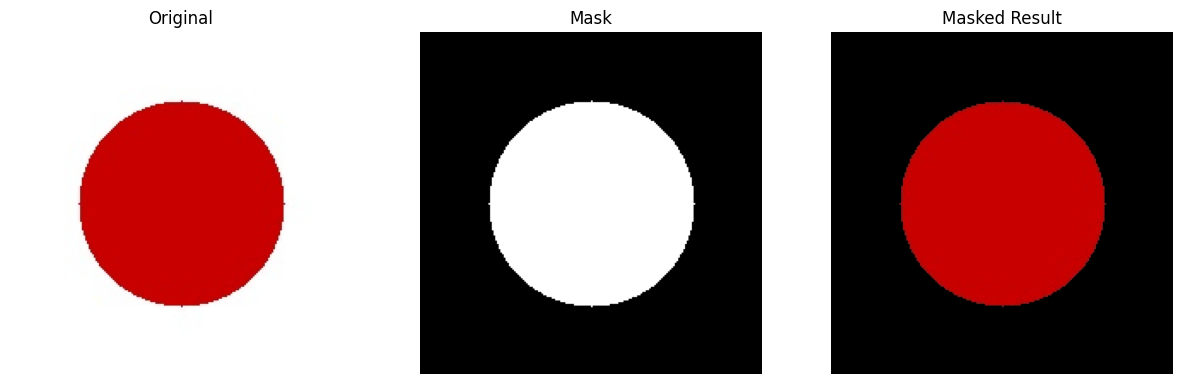

In [ ]:
# Initialize variable to avoid NameError if the previous cell is skipped
img_hsv = cv2.cvtColor(cv2.imread('red_apple.jpg'), cv2.COLOR_BGR2HSV) if os.path.exists('red_apple.jpg') else None
img_rgb = cv2.cvtColor(cv2.imread('red_apple.jpg'), cv2.COLOR_BGR2RGB) if os.path.exists('red_apple.jpg') else None

if img_hsv is not None:
    # Lower range for red
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)

    # Upper range for red
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

    # Combine masks
    full_mask = cv2.bitwise_or(mask1, mask2)
    result = cv2.bitwise_and(img_rgb, img_rgb, mask=full_mask)

    # Display results
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.title("Original"); plt.imshow(img_rgb); plt.axis('off')
    plt.subplot(1, 3, 2); plt.title("Mask"); plt.imshow(full_mask, cmap='gray'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.title("Masked Result"); plt.imshow(result); plt.axis('off')
    plt.show()

### 4. Color Table Task
I will now define the HSV ranges for the other fruits.

In [ ]:
def get_fruit_mask(img_path, lower, upper):
    img = cv2.imread(img_path)
    if img is None: return None
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
    return mask

# Define approximate working ranges
# Fruit | H_min | H_max | S_min | S_max | V_min | V_max
ranges = {
    'green_apple': [35, 85, 40, 255, 40, 255],
    'banana': [20, 35, 40, 255, 40, 255],
    'lime': [30, 90, 50, 255, 50, 255]
}

print("| Fruit | H_min | H_max | S_min | S_max | V_min | V_max |")
print("|-------|-------|-------|-------|-------|-------|-------|")
for fruit, r in ranges.items():
    print(f"| {fruit} | {r[0]} | {r[1]} | {r[2]} | {r[3]} | {r[4]} | {r[5]} |")

| Fruit | H_min | H_max | S_min | S_max | V_min | V_max |
|-------|-------|-------|-------|-------|-------|-------|
| green_apple | 35 | 85 | 40 | 255 | 40 | 255 |
| banana | 20 | 35 | 40 | 255 | 40 | 255 |
| lime | 30 | 90 | 50 | 255 | 50 | 255 |


### 5. Brightness/Contrast Adjustment
We will manually adjust brightness and compare it to OpenCV's built-in function.

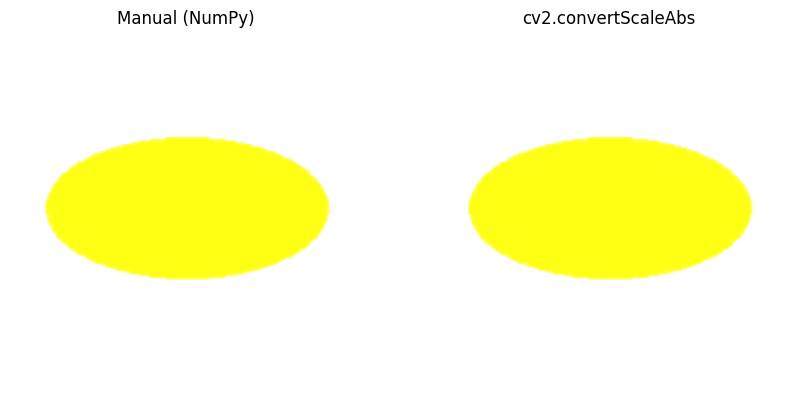

In [ ]:
img_banana = cv2.imread('banana.jpg')
if img_banana is not None:
    alpha = 1.3 # Contrast
    beta = 20   # Brightness

    # Manual adjustment
    manual_banana = np.clip(alpha * img_banana.astype(np.float32) + beta, 0, 255).astype(np.uint8)

    # OpenCV adjustment
    cv2_banana = cv2.convertScaleAbs(img_banana, alpha=alpha, beta=beta)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.title("Manual (NumPy)"); plt.imshow(cv2.cvtColor(manual_banana, cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.subplot(1, 2, 2); plt.title("cv2.convertScaleAbs"); plt.imshow(cv2.cvtColor(cv2_banana, cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.show()

## Part B — Histograms & Filtering
### 1. Strawberry Histogram and 2. Equalization

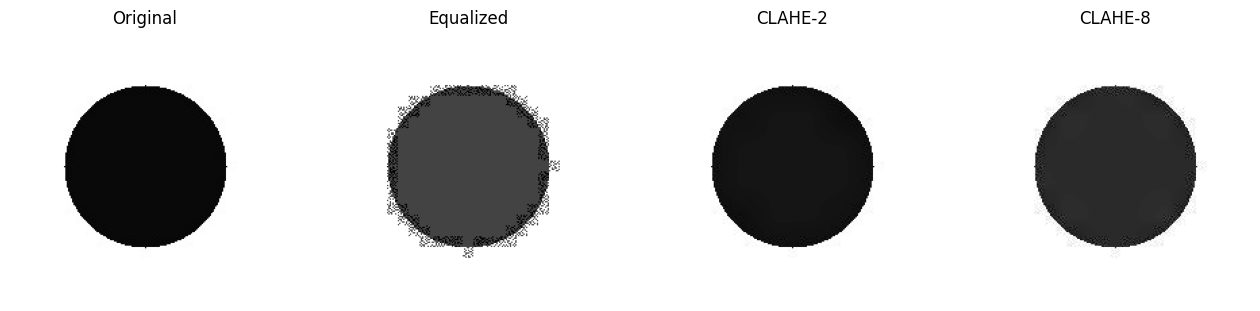

In [ ]:
img_straw = cv2.imread('strawberry.jpg', cv2.IMREAD_GRAYSCALE)
if img_straw is not None:
    # Histogram Equalization
    equ = cv2.equalizeHist(img_straw)

    # CLAHE
    clahe2 = cv2.createCLAHE(clipLimit=2.0).apply(img_straw)
    clahe8 = cv2.createCLAHE(clipLimit=8.0).apply(img_straw)

    images = [img_straw, equ, clahe2, clahe8]
    titles = ['Original', 'Equalized', 'CLAHE-2', 'CLAHE-8']

    plt.figure(figsize=(16, 4))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i])
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
    plt.show()

### 3. Noise Experiment (Orange)

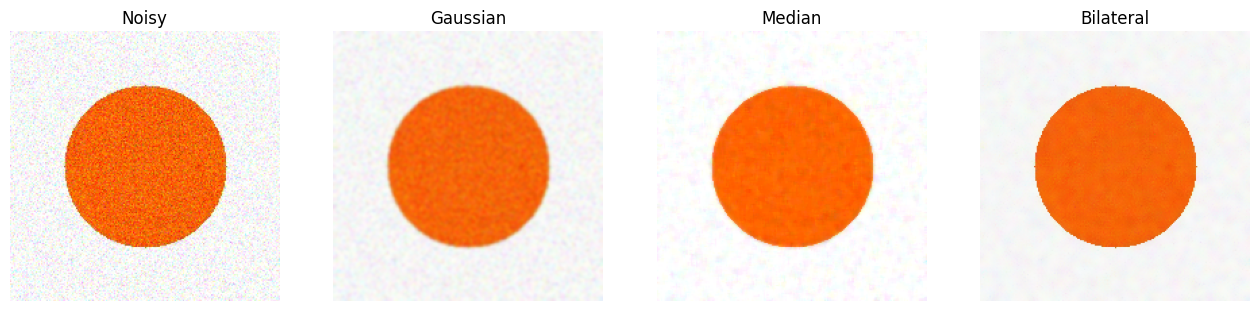

In [ ]:
img_orange = cv2.imread('orange.jpg')
if img_orange is not None:
    # Add Gaussian Noise
    noise = np.random.normal(0, 25, img_orange.shape).astype(np.int16)
    noisy_orange = np.clip(img_orange.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Filtering
    gauss_blur = cv2.GaussianBlur(noisy_orange, (5, 5), 0)
    median_blur = cv2.medianBlur(noisy_orange, 5)
    bilateral = cv2.bilateralFilter(noisy_orange, 9, 75, 75)

    titles = ['Noisy', 'Gaussian', 'Median', 'Bilateral']
    imgs = [noisy_orange, gauss_blur, median_blur, bilateral]

    plt.figure(figsize=(16, 4))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i])
        plt.imshow(cv2.cvtColor(imgs[i], cv2.COLOR_BGR2RGB))
        plt.axis('off')
    plt.show()

## Part C — Morphology & Mask Cleanup
We clean up the binary masks to remove noise and extract outlines.

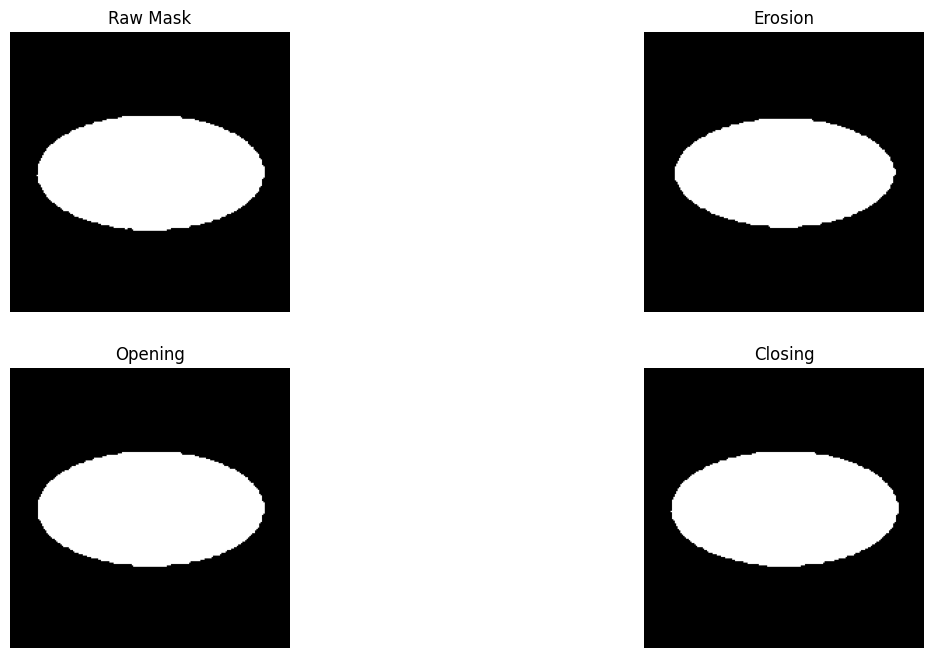

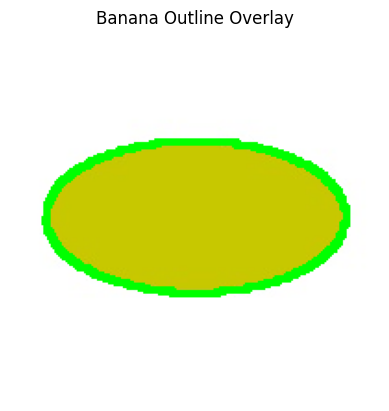

In [ ]:
# 5, 6, 7. Morphology on Banana Mask
img_banana = cv2.imread('banana.jpg')
if img_banana is not None:
    hsv_banana = cv2.cvtColor(img_banana, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_banana, np.array([15, 50, 50]), np.array([35, 255, 255]))

    kernel = np.ones((5,5), np.uint8)
    erosion = cv2.erode(mask, kernel, iterations=1)
    opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    gradient = cv2.morphologyEx(mask, cv2.MORPH_GRADIENT, kernel)

    # Display
    plt.figure(figsize=(15, 8))
    titles = ['Raw Mask', 'Erosion', 'Opening', 'Closing']
    imgs = [mask, erosion, opening, closing]
    for i in range(4):
        plt.subplot(2, 2, i+1); plt.title(titles[i]); plt.imshow(imgs[i], cmap='gray'); plt.axis('off')
    plt.show()

    # 7. Outline overlay
    outline_overlay = cv2.cvtColor(cv2.imread('banana.jpg'), cv2.COLOR_BGR2RGB)
    outline_overlay[gradient > 0] = [0, 255, 0] # Green outline
    plt.figure(); plt.title("Banana Outline Overlay"); plt.imshow(outline_overlay); plt.axis('off'); plt.show()

## Part D — Shape & Feature Detection
Including Canny edge detection, Harris corners, and Hough Circle counting.

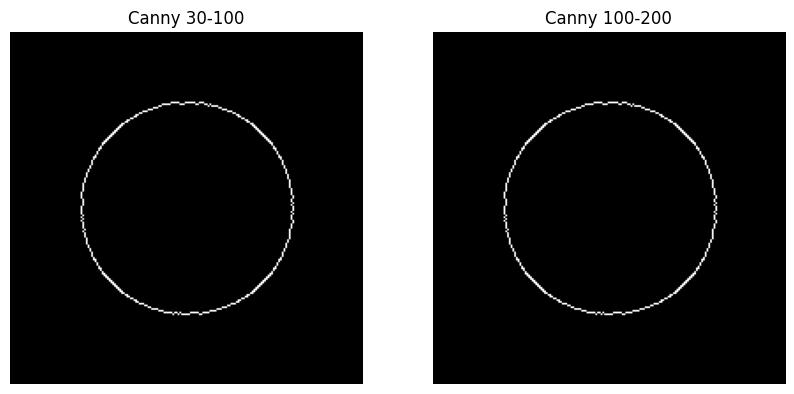

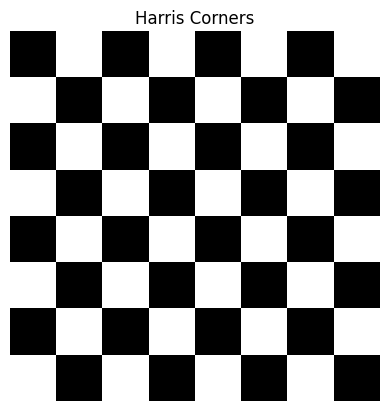

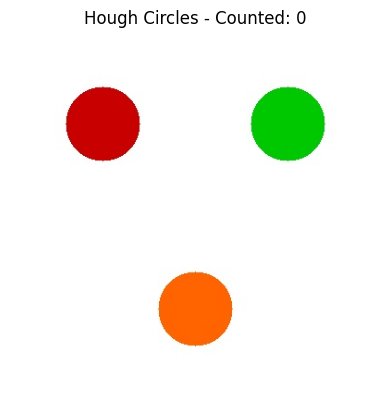

In [ ]:
# 10. Canny Edge Detection
img_ga = cv2.imread('green_apple.jpg', 0)
if img_ga is not None:
    canny1 = cv2.Canny(img_ga, 30, 100)
    canny2 = cv2.Canny(img_ga, 100, 200)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.title("Canny 30-100"); plt.imshow(canny1, cmap='gray'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.title("Canny 100-200"); plt.imshow(canny2, cmap='gray'); plt.axis('off')
    plt.show()

# 12. Harris Corners
chess = cv2.imread('chessboard.png', 0)
if chess is not None:
    dst = cv2.cornerHarris(chess, 2, 3, 0.04)
    chess_color = cv2.cvtColor(chess, cv2.COLOR_GRAY2RGB)
    chess_color[dst > 0.01 * dst.max()] = [255, 0, 0]
    plt.figure(); plt.title("Harris Corners"); plt.imshow(chess_color); plt.axis('off'); plt.show()

# 13. Hough Circle Count
bowl = cv2.imread('mixed_bowl.jpg')
if bowl is not None:
    gray_bowl = cv2.cvtColor(bowl, cv2.COLOR_BGR2GRAY)
    circles = cv2.HoughCircles(gray_bowl, cv2.HOUGH_GRADIENT, 1, 20, param1=50, param2=30, minRadius=30, maxRadius=100)

    bowl_res = cv2.cvtColor(bowl, cv2.COLOR_BGR2RGB)
    count = 0
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            cv2.circle(bowl_res, (i[0], i[1]), i[2], (0, 255, 0), 2)
            cv2.circle(bowl_res, (i[0], i[1]), 2, (0, 0, 255), 3)
            count += 1

    plt.figure(); plt.title(f"Hough Circles - Counted: {count}"); plt.imshow(bowl_res); plt.axis('off'); plt.show()

### 14. Full Deliverable Pipeline
Processing a single fruit through the entire workflow and saving the output.

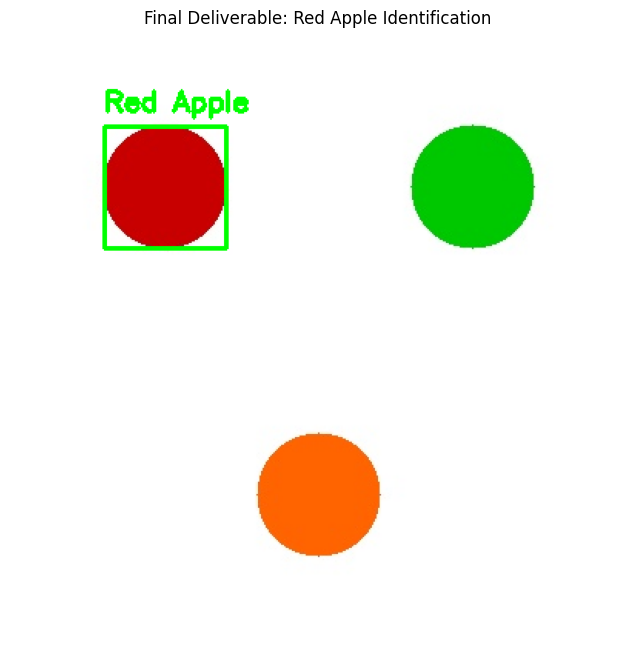

Final image saved as final_fruit_identification.jpg


In [ ]:
# Load bowl
bowl_bgr = cv2.imread('mixed_bowl.jpg')
if bowl_bgr is not None:
    # 1. Convert to RGB for display
    bowl_rgb = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2RGB)

    # 2. HSV Mask for Red Apple in the bowl
    hsv = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2HSV)
    lower_red = np.array([0, 100, 100])
    upper_red = np.array([10, 255, 255])
    mask = cv2.inRange(hsv, lower_red, upper_red)

    # 3. Morphological Cleanup
    kernel = np.ones((5,5), np.uint8)
    cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 4. Canny Edges
    edges = cv2.Canny(cleaned_mask, 100, 200)

    # 5. Find Bounding Box
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_output = bowl_rgb.copy()
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(final_output, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(final_output, 'Red Apple', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # 6. Display and Save
    plt.figure(figsize=(8, 8))
    plt.imshow(final_output)
    plt.title("Final Deliverable: Red Apple Identification")
    plt.axis('off')
    plt.show()

    # Saving result
    cv2.imwrite('final_fruit_identification.jpg', cv2.cvtColor(final_output, cv2.COLOR_RGB2BGR))
    print("Final image saved as final_fruit_identification.jpg")